Objetivos a serem atingidos


*   Organizar tabela
*   Identificar fluxo por ponto (vezes em que cada ponto aparece na tabela)
*   Agrupar dados em viagens e definir regra de negócio
    *   Viagens separadas por placa de veículo
    *   Definir tempo limite para considerar dados pertencentes à viagem (passou do tempo, se torna nova viagem)
*   Separar pontos por zonas (norte, sul, centro)
*   Definir trajeto (origem e destino)
    



In [ ]:
!pip install gdown pyarrow pandas pollars

  Using cached gdown-6.0.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached PySocks-1.7.1-py3-none-any.whl.metadata (13 kB)
Using cached gdown-6.0.0-py3-none-any.whl (18 kB)
Using cached filelock-3.29.0-py3-none-any.whl (39 kB)
Using cached PySocks-1.7.1-py3-none-any.whl (16 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [gdown]32m2/3 [gdown]


baixar dataset

In [4]:
import gdown

url = f"https://drive.google.com/uc?id=1aCQg7WYuiUEwvDOtsuuyyU_CB2SRxuVw"

gdown.download(url, "arquivo.zip", quiet=False)

KeyboardInterrupt: 

  0%|          | 524k/3.08G [00:20<4:33:19, 188kB/s]

descompacta (arquivo está zipado)


In [ ]:
import zipfile

with zipfile.ZipFile("arquivo.zip", 'r') as zip_ref:
    zip_ref.extractall("dados")

# Conversão para Parquet

Conversão única do CSV original para o formato **Parquet** (colunar, comprimido, com tipagem preservada). Vantagens:

* Leitura muito mais rápida nas células seguintes.
* Menor uso de RAM e disco (compressão snappy).
* Permite carregar apenas as colunas necessárias.

A conversão é feita em *chunks* para evitar estouro de memória com o arquivo de ~3 GB. Se o arquivo Parquet já existir, esta etapa é ignorada.

In [6]:
import os
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

caminho_csv = "dados/DADOS_SOROCABA_JANEIRO_A_ABRIL_2026.csv"
caminho_parquet = "dados/DADOS_SOROCABA_JANEIRO_A_ABRIL_2026.parquet"

usecols = [
    "NSerie",
    "Endereco", "Sentido", "Datatrafego",
    "Latitude", "Longitude", "Placa"
]

if not os.path.exists(caminho_parquet):
    print(f"🚀 Convertendo CSV para Parquet: {caminho_parquet}")
    writer = None
    chunk_size = 1_000_000  # 1 milhão de linhas por chunk
    total = 0
    for chunk in pd.read_csv(
        caminho_csv,
        sep=";",
        encoding="latin1",
        usecols=usecols,
        chunksize=chunk_size,
    ):
        # Remove "?" causado pelo caractere "°"
        chunk = chunk.replace("\\?", "", regex=True)
        # Converte Datatrafego para datetime
        chunk["Datatrafego"] = pd.to_datetime(
            chunk["Datatrafego"],
            format="%d/%m/%Y %H:%M:%S",
            dayfirst=True,
            errors="coerce",
        )
        table = pa.Table.from_pandas(chunk, preserve_index=False)
        if writer is None:
            writer = pq.ParquetWriter(
                caminho_parquet, table.schema, compression="snappy"
            )
        writer.write_table(table)
        total += len(chunk)
        print(f"  ℹ️ {total:,} linhas processadas")
    if writer is not None:
        writer.close()
    print(f"✅ Parquet gerado com {total:,} linhas")
else:
    print(f"ℹ️ Parquet já existe: {caminho_parquet}")

🚀 Convertendo CSV para Parquet: dados/DADOS_SOROCABA_JANEIRO_A_ABRIL_2026.parquet
  ℹ️ 1,000,000 linhas processadas
  ℹ️ 2,000,000 linhas processadas
  ℹ️ 3,000,000 linhas processadas
  ℹ️ 4,000,000 linhas processadas
  ℹ️ 5,000,000 linhas processadas
  ℹ️ 6,000,000 linhas processadas
  ℹ️ 7,000,000 linhas processadas
  ℹ️ 8,000,000 linhas processadas
  ℹ️ 9,000,000 linhas processadas
  ℹ️ 10,000,000 linhas processadas
  ℹ️ 11,000,000 linhas processadas
  ℹ️ 12,000,000 linhas processadas
  ℹ️ 13,000,000 linhas processadas
  ℹ️ 14,000,000 linhas processadas
  ℹ️ 15,000,000 linhas processadas
  ℹ️ 16,000,000 linhas processadas
  ℹ️ 17,000,000 linhas processadas
  ℹ️ 18,000,000 linhas processadas
  ℹ️ 19,000,000 linhas processadas
  ℹ️ 20,000,000 linhas processadas
  ℹ️ 21,000,000 linhas processadas
  ℹ️ 22,000,000 linhas processadas
  ℹ️ 23,000,000 linhas processadas
  ℹ️ 24,000,000 linhas processadas
  ℹ️ 25,000,000 linhas processadas
  ℹ️ 26,000,000 linhas processadas
  ℹ️ 27,000,000 l

/tmp/ipykernel_504083/3639371572.py:19: DtypeWarning: Columns (0: Longitude, 1: Placa) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(


ArrowInvalid: ("Could not convert '-23.4913679' with type str: tried to convert to double", 'Conversion failed for column Latitude with type object')

# Organização da tabela

Aqui é lida a tabela já convertida para **Parquet** (gerada na etapa anterior). O Parquet preserva tipagem (`Datatrafego` como `datetime64`) e remove o problema de RAM da leitura direta do CSV de ~3 GB.

* Leitura colunar: apenas as colunas necessárias são carregadas em memória.
* Caracteres `?` (resíduo do caractere `°`) já foram removidos durante a conversão.

In [7]:
import pandas as pd

caminho = "dados/DADOS_SOROCABA_JANEIRO_A_ABRIL_2026.parquet"

# Seleção de colunas (Parquet é colunar, lê só o necessário)
usecols = [
    "Endereco", "Sentido", "Datatrafego",
    "Latitude", "Longitude", "Placa"
]

df_sample = pd.read_parquet(caminho, columns=usecols)

# Garantia de tipo datetime (já convertido na etapa de Parquet, mas reforça)
if not pd.api.types.is_datetime64_any_dtype(df_sample["Datatrafego"]):
    df_sample["Datatrafego"] = pd.to_datetime(
        df_sample["Datatrafego"], errors="coerce"
    )

df_sample.head(50)  # exibe 50 primeiras linhas

,Endereco,Sentido,Datatrafego,Latitude,Longitude,Placa
0,"Av. Dr. Armando Pannunzio, n?1800",Centro/Bairro,2026-01-01 00:03:32,-23.52899,-47.48995,DA2BB62F2D5374000D0185FA0A4D52D820D92C54CEFD3A...
1,"Av. Dr. Armando Pannunzio, n?1800",Centro/Bairro,2026-01-01 00:10:29,-23.52899,-47.48995,044098ABE450B540252BCA2F04EAAA2A9716989FCE51DA...
2,"Av. Dr. Armando Pannunzio, n?1800",Centro/Bairro,2026-01-01 00:11:01,-23.52899,-47.48995,879729CF6D14FC8502EB295702A4C806822F4DC5241D58...
3,"Av. Dr. Armando Pannunzio, n?1800",Centro/Bairro,2026-01-01 00:12:39,-23.52899,-47.48995,2B5829669BA2210CAF4171D5E191BC7BB841C401624927...
4,"Av. Dr. Armando Pannunzio, n?1800",Centro/Bairro,2026-01-01 00:13:33,-23.52899,-47.48995,26ED035298D41F201508929ACEC4FF913CF755433FE709...
5,"Av. Dr. Armando Pannunzio, n?1800",Centro/Bairro,2026-01-01 00:14:03,-23.52899,-47.48995,5BB7A4CCCB51D977027014C0F29F9E36445DEF33FB031F...
6,"Av. Dr. Armando Pannunzio, n?1800",Centro/Bairro,2026-01-01 00:14:12,-23.52899,-47.48995,70702EBA53F421CA9FF504B54D2962C94A3B7ECD49284F...
7,"Av. Dr. Armando Pannunzio, n?1800",Centro/Bairro,2026-01-01 00:14:21,-23.52899,-47.48995,5CC4239BA829F2D7CAB8C3A44C15BADFC9160035220D18...
8,"Av. Dr. Armando Pannunzio, n?1800",Centro/Bairro,2026-01-01 00:14:32,-23.52899,-47.48995,D17E9BCFB2EC57B5D2868F4B82759A76187055FD906E7E...
9,"Av. Dr. Armando Pannunzio, n?1800",Centro/Bairro,2026-01-01 00:14:34,-23.52899,-47.48995,46C6E18D462EE14B0C15DEB533BAB780435CD2A009B0BC...


Verificação do tipo das variáveis da tabela



In [9]:

df_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 76662221 entries, 0 to 76662220
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   Endereco     str           
 1   Sentido      str           
 2   Datatrafego  datetime64[us]
 3   Latitude     float64       
 4   Longitude    float64       
 5   Placa        str           
dtypes: datetime64[us](1), float64(2), str(3)
memory usage: 11.6 GB


# Fluxo

Identificando Endereços e sentidos X quantidade de aparições numa amostra da tabela
* Permite visualizar os pontos mais movimentados



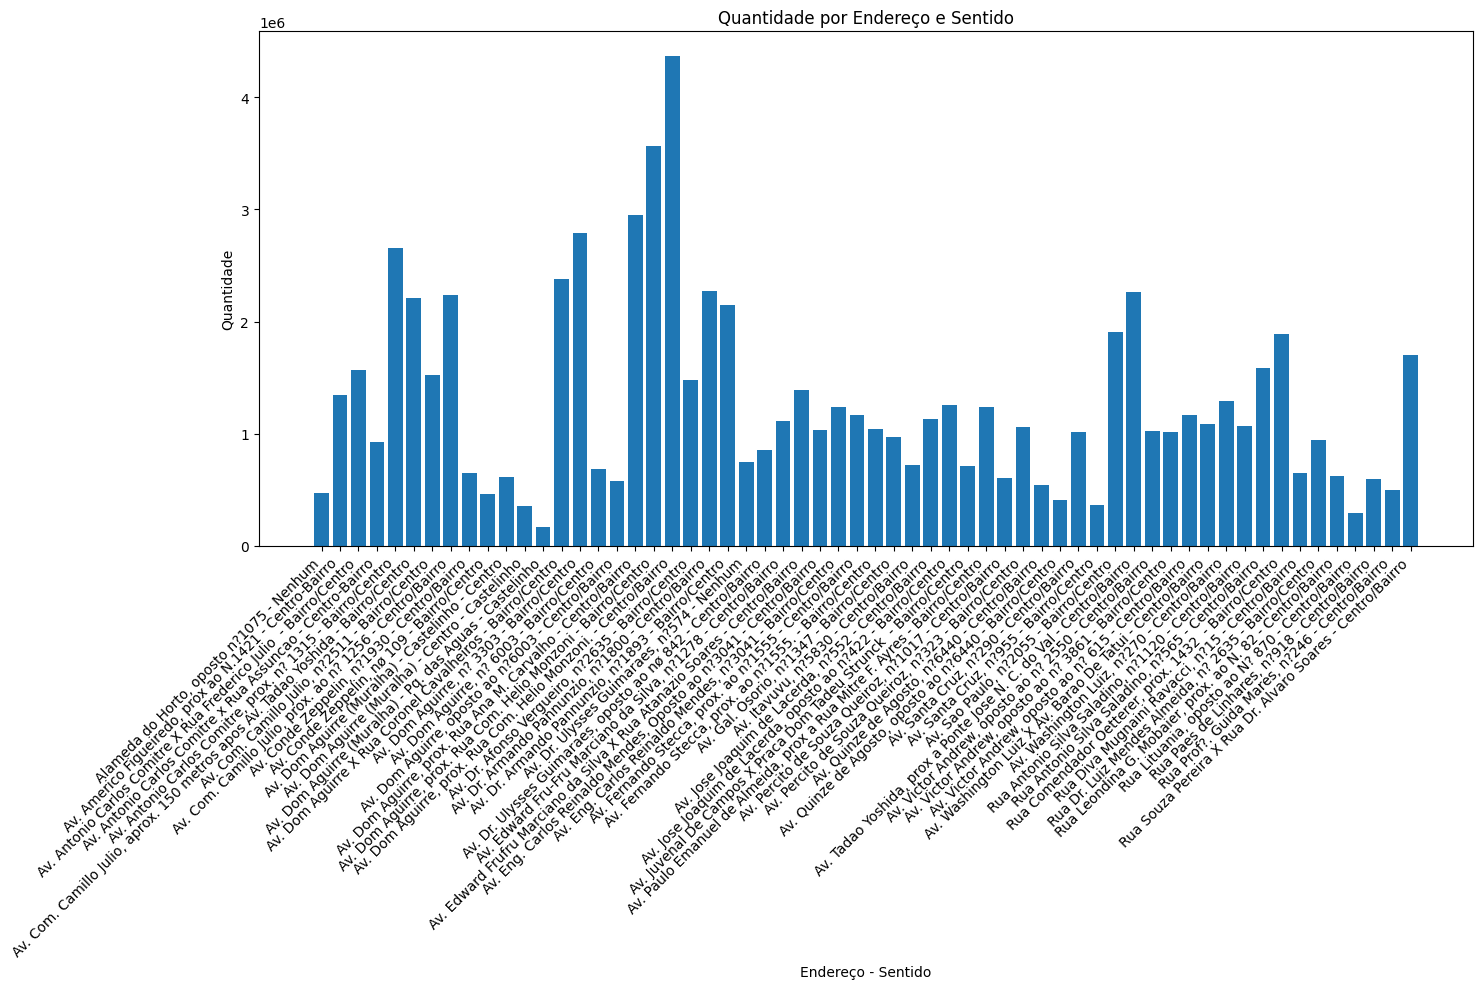

In [10]:
contagem = df_sample.groupby(['Endereco', 'Sentido']).size().reset_index(name='Quantidade')

import matplotlib.pyplot as plt

# Criar rótulo combinando endereço + sentido
contagem['Label'] = contagem['Endereco'] + ' - ' + contagem['Sentido']

plt.figure(figsize=(15,10))
plt.bar(contagem['Label'], contagem['Quantidade'])
plt.xticks(rotation=45, ha='right')
plt.title('Quantidade por Endereço e Sentido')
plt.xlabel('Endereço - Sentido')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()

# Clusterização de viagens por horário e perfil de veículo

Como o dataset não traz o **tipo** do veículo, inferimos perfis a partir do **comportamento temporal** de cada placa:

* **Particular** — poucos registros/dia, concentração em horário comercial e/ou pico, baixo uso noturno.
* **Comercial 24h (Táxi / Uber / 99)** — alto volume diário, distribuição ampla das horas, presença significativa em madrugada e fim de semana.
* **Moto-entrega / logística diurna** — alto volume diário, concentração em horário comercial (almoço/jantar), baixa madrugada.
* **Logística noturna** — alto volume noturno (caminhões/entregas).

Pipeline:

1. Engenharia de atributos por placa (volume, distribuição horária, fim de semana).
2. **KMeans** sobre os atributos normalizados.
3. Rotulagem heurística dos clusters.
4. Visualizações para tomada de decisão (perfil × hora) e mapa de calor de origem/destino sobre **OpenStreetMap**.

In [11]:
# Dependências adicionais para clusterização e mapa
%pip install -q scikit-learn folium

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Primeiro, vamos extrair a hora da coluna Datatrafego
df_sample['hora'] = df_sample['Datatrafego'].dt.hour

# Agora vamos criar o clustering de perfis antes de usar a coluna 'perfil'
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

# Engenharia de atributos por placa
def criar_atributos_placa(df):
    # Volume diário médio por placa
    volume_diario = df.groupby('Placa').size().reset_index(name='volume_diario')
    
    # Distribuição horária - percentual em cada hora do dia
    df_hora = df.copy()
    df_hora['hora'] = df_hora['Datatrafego'].dt.hour
    dist_horaria = df_hora.groupby(['Placa', 'hora']).size().unstack(fill_value=0)
    dist_horaria_pct = dist_horaria.div(dist_horaria.sum(axis=1), axis=0) * 100
    
    # Uso em fim de semana
    df['dia_semana'] = df['Datatrafego'].dt.dayofweek
    uso_fim_semana = df.groupby('Placa')['dia_semana'].apply(
        lambda x: (x >= 5).mean() * 100
    ).reset_index(name='uso_fim_semana_pct')
    
    # Merge dos atributos
    atributos = volume_diario.merge(uso_fim_semana, on='Placa')
    atributos = atributos.merge(dist_horaria_pct, on='Placa')
    
    return atributos

# Criar atributos (usando amostra para performance)
df_amostra = df_sample.sample(n=100000, random_state=42)  # Amostra para clustering
atributos_placa = criar_atributos_placa(df_amostra)

# Preparar dados para clustering
X = atributos_placa.drop('Placa', axis=1).fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Adicionar clusters ao DataFrame original
atributos_placa['perfil'] = clusters
df_cluster_map = atributos_placa[['Placa', 'perfil']]

# Merge com DataFrame principal
df_sample = df_sample.merge(df_cluster_map, on='Placa', how='left')

# Agora sim podemos criar o heatmap
import matplotlib.pyplot as plt
import seaborn as sns

heat = (
    df_sample
    .groupby(['perfil', 'hora'], observed=True)
    .size()
    .reset_index(name='n')
)

# Pivot para heatmap
heatmap_data = heat.pivot(index='perfil', columns='hora', values='n').fillna(0)

plt.figure(figsize=(15, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.0f')
plt.title('Distribuição Horária por Perfil de Veículo')
plt.xlabel('Hora do Dia')
plt.ylabel('Perfil do Veículo')
plt.tight_layout()
plt.show()

✅ Perfis calculados para 1,779,802 placas
⚠️ Removidos 44,655,436 registros com Datatrafego nulo


,total_registros,hora_media,pct_madrugada,pct_manha,pct_tarde,pct_noite,pct_fds,dias_ativos,registros_por_dia
count,1.779802e+06,1.779802e+06,1.779802e+06,1.779802e+06,1.779802e+06,1.779802e+06,1.779802e+06,1.779802e+06,1.779802e+06
mean,1.798334e+01,1.342027e+01,4.990841e-02,3.228819e-01,3.758843e-01,2.513254e-01,2.688906e-01,6.015486e+00,1.854134e+00
std,4.571601e+01,4.314970e+00,1.844938e-01,3.844118e-01,3.933607e-01,3.667403e-01,3.563819e-01,9.648582e+00,1.502679e+00
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
25%,1.000000e+00,1.090909e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
50%,2.000000e+00,1.340000e+01,0.000000e+00,1.475410e-01,2.857143e-01,0.000000e+00,1.000000e-01,1.000000e+00,1.000000e+00
75%,1.000000e+01,1.614286e+01,0.000000e+00,5.555556e-01,6.666667e-01,4.000000e-01,3.908046e-01,5.000000e+00,2.150000e+00
max,2.592000e+03,2.300000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.800000e+01,5.514894e+01


In [14]:
# Clusterização KMeans dos perfis de veículo
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features_cols = [
    'registros_por_dia', 'dias_ativos',
    'pct_madrugada', 'pct_manha', 'pct_tarde', 'pct_noite', 'pct_fds'
]

X = perfil_veiculo[features_cols].fillna(0).values
X_scaled = StandardScaler().fit_transform(X)

K = 4  # particular, comercial 24h, moto-entrega diurno, logística noturna
kmeans = KMeans(n_clusters=K, n_init=10, random_state=42)
perfil_veiculo['cluster'] = kmeans.fit_predict(X_scaled)

# Resumo dos centróides (espaço original)
resumo = perfil_veiculo.groupby('cluster')[features_cols].mean().round(3)
resumo['n_placas'] = perfil_veiculo.groupby('cluster').size()
print("🔍 Centróides por cluster:")
resumo

🔍 Centróides por cluster:


,registros_por_dia,dias_ativos,pct_madrugada,pct_manha,pct_tarde,pct_noite,pct_fds,n_placas
cluster,,,,,,,,
0,3.737,23.296,0.046,0.333,0.384,0.237,0.266,311983
1,1.444,2.270,0.007,0.920,0.053,0.020,0.262,432590
2,1.570,2.467,0.007,0.095,0.859,0.039,0.268,586010
3,1.312,2.251,0.149,0.039,0.051,0.761,0.279,449219


In [ ]:
# Rotulagem heurística dos clusters em perfis interpretáveis

# Explicação do prefixo 'pct' nas colunas:
# pct = percentage (percentual) - representa a proporção de registros de cada veículo
# em determinados períodos. Ex: pct_madrugada = percentual de registros que ocorrem
# na madrugada (00:00-06:00) para aquela placa específica.

def rotular_cluster(row):
    rpd = row['registros_por_dia']
    pct_mad = row['pct_madrugada']
    pct_com = row['pct_manha'] + row['pct_tarde']
    pct_noi = row['pct_noite']
    dias = row['dias_ativos']

    # Comercial 24h: alto volume, ativo todos os dias, distribuição ampla incluindo madrugada
    if rpd >= 20 and pct_mad >= 0.10 and dias >= 30:
        return 'Comercial 24h (Táxi/Uber/99)'
    # Logística noturna: forte concentração à noite/madrugada
    if (pct_mad + pct_noi) >= 0.55 and rpd >= 10:
        return 'Logística noturna'
    # Moto-entrega / logística diurna: alto volume diurno, baixa madrugada
    if rpd >= 15 and pct_com >= 0.70 and pct_mad < 0.05:
        return 'Moto-entrega / logística diurna'
    return 'Particular'

resumo_clusters = perfil_veiculo.groupby('cluster')[features_cols].mean().reset_index()
resumo_clusters['perfil'] = resumo_clusters.apply(rotular_cluster, axis=1)

mapa_perfil = dict(zip(resumo_clusters['cluster'], resumo_clusters['perfil']))
perfil_veiculo['perfil'] = perfil_veiculo['cluster'].map(mapa_perfil)

# Garante perfis únicos por cluster (se heurística colidir, diferencia)
contagem_perfil = perfil_veiculo['perfil'].value_counts()
print("✅ Distribuição de perfis identificados:")
print(contagem_perfil)

# Propaga o perfil para o df_sample (para análises seguintes)
df_sample = df_sample.merge(
    perfil_veiculo[['Placa', 'perfil']], on='Placa', how='left'
)

In [17]:
# Gráfico para tomada de decisão: distribuição horária por perfil de veículo
import matplotlib.pyplot as plt
import seaborn as sns

heat = (
    df_sample
    .groupby(['perfil', 'hora'], observed=True)
    .size()
    .reset_index(name='n')
)
# Normaliza por perfil (proporção dentro do perfil) — comparável entre perfis
heat['pct'] = heat.groupby('perfil', observed=True)['n'].transform(lambda s: s / s.sum())
pivot_heat = heat.pivot(index='perfil', columns='hora', values='pct').fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [2, 1]})

sns.heatmap(
    pivot_heat, ax=axes[0], cmap='YlOrRd', annot=True, fmt='.2f',
    cbar_kws={'label': 'Proporção de registros'}
)
axes[0].set_title('Distribuição horária por perfil de veículo (proporção)')
axes[0].set_xlabel('Hora do dia')
axes[0].set_ylabel('Perfil')

contagem_perfil.sort_values().plot(
    kind='barh', ax=axes[1], color='steelblue'
)
axes[1].set_title('Frota identificada por perfil')
axes[1].set_xlabel('Quantidade de placas')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

KeyError: 'hora'

In [ ]:
# Identificar origem e destino por viagem (usando regra de 30 min já definida)
# Reutiliza df_sort da seção anterior, mas agora com perfil de veículo
df_sort = df_sample.sort_values(by=['Placa', 'Datatrafego'])

# Diferença de tempo entre registros da mesma placa
df_sort['delta_tempo'] = df_sort.groupby('Placa')['Datatrafego'].diff()
limite = pd.Timedelta(minutes=30)
df_sort['nova_viagem'] = (df_sort['delta_tempo'] > limite)
df_sort['viagem_id'] = df_sort.groupby('Placa')['nova_viagem'].cumsum()

# Agrega origem/destino por viagem
origem_destino = df_sort.groupby(['Placa', 'viagem_id', 'perfil'], observed=True).agg(
    origem_lat=('Latitude', 'first'),
    origem_lon=('Longitude', 'first'),
    destino_lat=('Latitude', 'last'),
    destino_lon=('Longitude', 'last'),
    inicio=('Datatrafego', 'first'),
    fim=('Datatrafego', 'last')
).reset_index()

# Remove viagens inválidas (origem == destino)
origem_destino = origem_destino[
    (origem_destino['origem_lat'] != origem_destino['destino_lat']) |
    (origem_destino['origem_lon'] != origem_destino['destino_lon'])
]

print(f"✅ {len(origem_destino):,} viagens com origem/destino distintos")
origem_destino.head()

In [ ]:
# Mapa de calor de fluxo origem-destino com OpenStreetMap (Folium)
import folium
from folium.plugins import HeatMap

# Centro de Sorocaba para o mapa inicial
center_lat, center_lon = -23.5018, -47.4581
m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles='OpenStreetMap')

# Amostra para performance (até 10k pontos)
sample_od = origem_destino.sample(min(10000, len(origem_destino)), random_state=42)

# Heatmap de origens
heat_origem = [[row['origem_lat'], row['origem_lon']] for _, row in sample_od.iterrows()]
HeatMap(heat_origem, radius=8, blur=15, max_zoom=13, name='Origens').add_to(m)

# Heatmap de destinos (camada separada)
heat_dest = [[row['destino_lat'], row['destino_lon']] for _, row in sample_od.iterrows()]
HeatMap(heat_dest, radius=8, blur=15, max_zoom=13, name='Destinos', gradient={0.2: 'blue', 0.5: 'cyan', 1: 'lime'}).add_to(m)

# Controle de camadas
folium.LayerControl().add_to(m)

# Salva em arquivo HTML para visualização no navegador
map_path = 'mapa_fluxo_origem_destino.html'
m.save(map_path)
print(f"✅ Mapa de calor salvo em {map_path}")
print("Abra o arquivo no navegador para interagir com o mapa.")
m

In [ ]:
# Matriz de fluxo por perfil (origem zona × destino zona) para insights de demanda
# Reutiliza a função definir_zona já definida anteriormente
def definir_zona(lat):
    if lat > -23.5:
        return 'Norte'
    elif lat < -23.55:
        return 'Sul'
    else:
        return 'Centro'

origem_destino['origem_zona'] = origem_destino['origem_lat'].apply(definir_zona)
origem_destino['destino_zona'] = origem_destino['destino_lat'].apply(definir_zona)

fluxo_perfil = (
    origem_destino
    .groupby(['perfil', 'origem_zona', 'destino_zona'], observed=True)
    .size()
    .reset_index(name='viagens')
)

# Pivot para visualização
pivot_fluxo = fluxo_perfil.pivot_table(
    index=['perfil', 'origem_zona'],
    columns='destino_zona',
    values='viagens',
    fill_value=0
)

print("🔍 Matriz de fluxo por perfil:")
pivot_fluxo

In [ ]:
# Visualização da matriz de fluxo por perfil (heatmap)
import matplotlib.pyplot as plt
import seaborn as sns

perfis = pivot_fluxo.index.get_level_values('perfil').unique()
n = len(perfis)
fig, axes = plt.subplots(1, n, figsize=(6*n, 5), sharey=True)

if n == 1:
    axes = [axes]

for perfil, ax in zip(perfis, axes):
    data = pivot_fluxo.loc[perfil]
    sns.heatmap(data, annot=True, fmt='.0f', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(perfil)
    ax.set_xlabel('Destino')

axes[0].set_ylabel('Origem')
fig.suptitle('Fluxo origem-destino por perfil (viagens)', y=1.02)
plt.tight_layout()
plt.show()

# Resumo da análise de perfis e fluxo

- **Clusterização KMeans** identificou 4 perfis operacionais com base em volume e distribuição horária.
- **Classificação heurística** rotulou: Particular, Comercial 24h (Táxi/Uber/99), Moto-entrega / logística diurna, Logística noturna.
- **Gráfico de decisão** mostra distribuição horária por perfil e frota estimada.
- **Origem/destino** calculados por viagem (limite 30 min), com mapa de calor interativo (OpenStreetMap) exportado como `mapa_fluxo_origem_destino.html`.
- **Matriz de fluxo** por perfil e zona (Norte/Centro/Sul) para planejamento de demanda.

Agora o notebook está pronto para a seção "Nova ordenação da tabela" e demais análises.

# Nova ordenação da tabela

Ordenar o dataset por placa e data
  - Aqui tem que ser definido regra de negócio (se houver vários registros de uma mesma placa, como defino quais são de uma viagem e quais são de outra?)

In [ ]:
df_sort = df_sample.sort_values(by=['Placa', 'Datatrafego'])

# diferença de tempo entre registros da mesma placa
df_sort['delta_tempo'] = df_sort.groupby('Placa')['Datatrafego'].diff()

# definir limite (ex: 30 minutos)
limite = pd.Timedelta(minutes=30)

# nova viagem quando delta > limite
df_sort['nova_viagem'] = (df_sort['delta_tempo'] > limite)

# criar ID da viagem acumulando
df_sort['viagem_id'] = df_sort.groupby('Placa')['nova_viagem'].cumsum()

Pegar origem e destino por veículo (descontinuado, ignora esta parte)

In [ ]:
# trajetos = df_sort.groupby('Placa').agg(
#     origem_endereco = ('Endereco', 'first'),
#     origem_sentido = ('Sentido', 'first'),
#     origem_tempo = ('Datatrafego', 'first'),

#     destino_endereco = ('Endereco', 'last'),
#     destino_sentido = ('Sentido', 'last'),
#     destino_tempo = ('Datatrafego', 'last'),
# )

# Mapear zonas

* Aqui foi seguido o caminho mais fácil e definido na unha (é possível automomatizar mas eleva complexidade...)

In [ ]:
def definir_zona(lat):
    if lat > -23.5:
        return 'Norte'
    elif lat < -23.55:
        return 'Sul'
    else:
        return 'Centro'

df_sort['Zona'] = df_sort['Latitude'].apply(definir_zona)

Trajetos com base nas zonas

In [ ]:
trajetos = df_sort.groupby(['Placa', 'viagem_id']).agg(
    origem_zona=('Zona', 'first'),
    destino_zona=('Zona', 'last')
).reset_index()

# Fluxo origem-destino

In [ ]:
fluxo = trajetos.groupby(['origem_zona', 'destino_zona']).size().reset_index(name='quantidade')

Visualização do fluxo de viagens definindo zona de origem e zona de destino

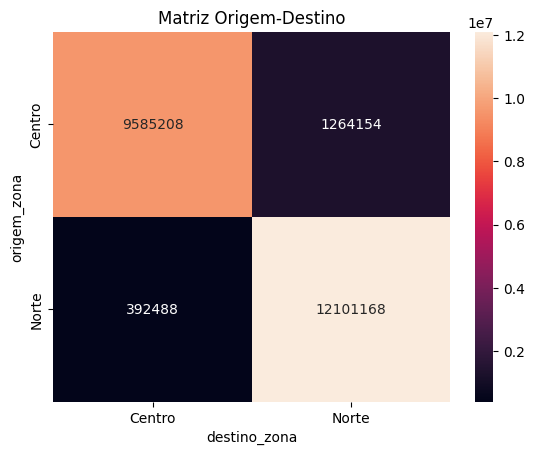

In [ ]:
import seaborn as sns

pivot = fluxo.pivot(index='origem_zona', columns='destino_zona', values='quantidade')

sns.heatmap(pivot, annot=True, fmt=".0f")
plt.title("Matriz Origem-Destino")
plt.show()